# Import các thư viện cần thiết #

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load dữ liệu
data = pd.read_csv('D:\\Tony\\House Price Predict\\Housing.csv')
print(data.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [ ]:
# Kiểm tra thông tin và thống kê cơ bản của dữ liệu
data.info()
data.describe()


<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [ ]:
# Ta thấy có 13 cột trong đó cột đầu tiên là giá nhà. Có một số features không có định dạng số nên ta chuyển 
# chúng thành số bằng cách sử dụng one-hot encoding
# Một số features cần chuyển là:
# -mainroad -> 0 hoặc 1
# -guestroom -> 0 hoặc 1
# -basement -> 0 hoặc 1
# -hotwaterheating -> 0 hoặc 1
# -airconditioning -> 0 hoặc 1
# -prefarea -> 0 hoặc 1
# -furnishingstatus -> 0, 1, 2 (đại diện cho unfurnished, semi-furnished, furnished)

In [9]:
data['mainroad'] = data['mainroad'].map({'yes': 1, 'no': 0})
data['guestroom'] = data['guestroom'].map({'yes': 1, 'no': 0})
data['basement'] = data['basement'].map({'yes': 1, 'no': 0})
data['hotwaterheating'] = data['hotwaterheating'].map({'yes': 1, 'no': 0})
data['airconditioning'] = data['airconditioning'].map({'yes': 1, 'no': 0})
data['prefarea'] = data['prefarea'].map({'yes': 1, 'no': 0})
data['furnishingstatus'] = data['furnishingstatus'].map({'unfurnished': 0, 'semi-furnished': 1, 'furnished': 2})

print(data.head())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus  
0                 2  
1                 2  
2                 1  
3                 2  
4                 2  


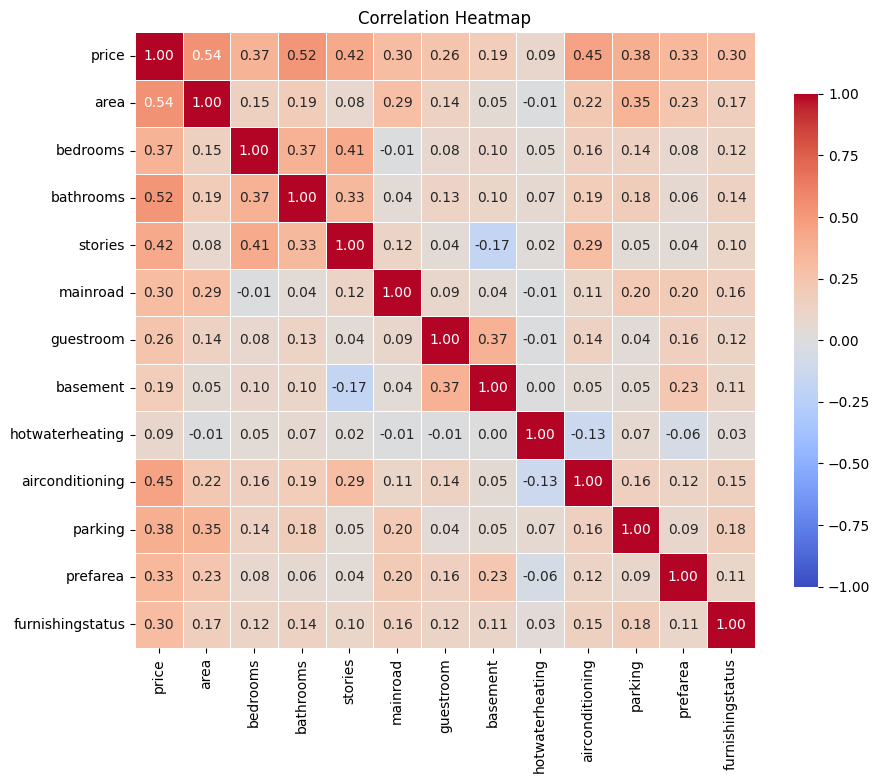

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(),
            annot=True, 
            fmt=".2f",         # Định dạng 2 chữ số thập phân
            cmap='coolwarm', 
            vmin=-1, vmax=1,   # Cố định thang đo từ -1 đến 1
            center=0,          # Đặt điểm giữa là 0
            linewidths=.5,     # Thêm đường kẻ giữa các ô
            cbar_kws={"shrink": .8}) # Thu nhỏ thanh màu cho cân đối
plt.title('Correlation Heatmap')
plt.show()


In [ ]:
# Từ heatmap ta có thể thấy rằng các features không quá tương quan với nhau, điều này "tốt"
# Các features có tương quan cao với giá nhà là: area, bathrooms, airconditioning, stories (>40%)

In [12]:
# Bây giờ ta đã có dữ liệu sạch sẽ, ta sẽ tách dữ liệu thành features (X) và target (y)
x = data.drop('price', axis=1).values
y_true = data['price'].values


In [13]:
# Chuẩn hóa dữ liệu
from sklearn.preprocessing import StandardScaler
scaler_X = StandardScaler()
x = scaler_X.fit_transform(x)

scaler_y = StandardScaler()
y_true = scaler_y.fit_transform(y_true.reshape(-1, 1)).flatten()

# Bắt đầu xây dựng mô hình hồi quy tuyến tính đơn giản


In [14]:
# Khởi tạo các trọng số và bias
w = np.random.rand(x.shape[1])
b = 0
learning_rate = 0.00001

In [15]:
#hàm dự đoán (forward pass)
def forward_pass(x, w, b):
    return np.dot(x, w) + b

In [32]:
#hàm tính loss
def compute_loss(y_true, y_pred, threshold = 3):
    loss = np.zeros_like(y_true)
    for i in range(len(y_true)):
        if(abs(y_true[i] - y_pred[i]) > threshold):
            loss[i] = 1/2 * (y_true[i] - y_pred[i]) ** 2
        else:
            loss[i] = threshold * abs(y_true[i] - y_pred[i]) - 1/2 * threshold ** 2
    return np.mean(loss)


In [30]:
#hàm tính đạo hàm
def compute_gradient(x, y_true, y_pred, threshold=3):
    n = len(y_true)
    errors = y_true - y_pred
    
    # Khởi tạo mảng chứa đạo hàm của Loss đối với y_pred
    d_loss_dy = np.zeros(n)
    
    # Điều kiện 1: |error| > threshold (MSE logic)
    mask_mse = np.abs(errors) > threshold
    d_loss_dy[mask_mse] = -errors[mask_mse]
    
    # Điều kiện 2: |error| <= threshold (MAE logic)
    mask_mae = np.abs(errors) <= threshold
    d_loss_dy[mask_mae] = -threshold * np.sign(errors[mask_mae])
    
    # Tính trung bình gradient cho weight (w) và bias (b)
    # Đạo hàm của y_pred theo w là x, theo b là 1
    dw = np.mean(d_loss_dy * x[:, 0]) 
    db = np.mean(d_loss_dy)
    
    return dw, db

In [33]:
#Luyện mô hình
for epoch in range(1000):
    # Dự đoán
    y_pred = forward_pass(x, w, b)
    
    # Tính loss
    loss = compute_loss(y_true, y_pred)
    
    # Tính gradients
    dw, db = compute_gradients(x, y_true, y_pred)
    
    # Cập nhật trọng số và bias
    w -= learning_rate * dw
    b -= learning_rate * db
    
    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {loss}')

Epoch 0, Loss: 1.1992500349864939
Epoch 100, Loss: 1.1734459072597065
Epoch 200, Loss: 1.1478129973620008
Epoch 300, Loss: 1.1223855027025207
Epoch 400, Loss: 1.0971756351037785
Epoch 500, Loss: 1.0721375506079933
Epoch 600, Loss: 1.0472605509695716
Epoch 700, Loss: 1.0225714142702176
Epoch 800, Loss: 0.9980425375031559
Epoch 900, Loss: 0.9736703863179846


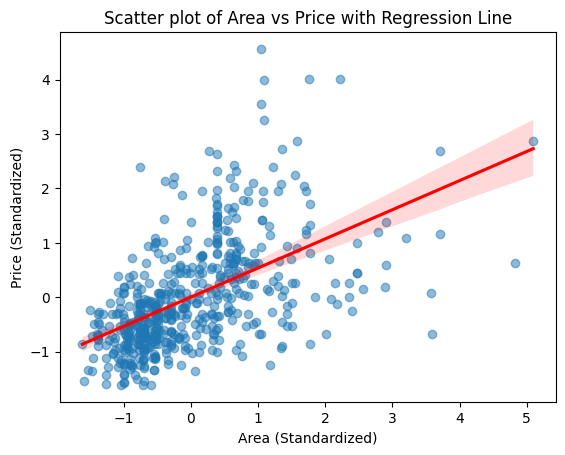

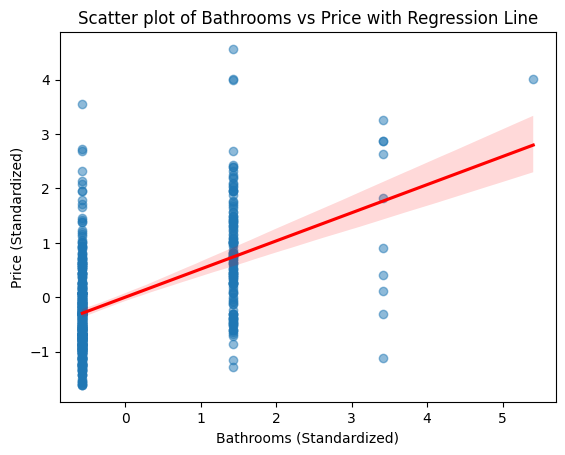

In [34]:
# vẽ scatter theo area
sns.regplot(x=x[:, 0], y=y_true, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Scatter plot of Area vs Price with Regression Line')
plt.xlabel('Area (Standardized)')
plt.ylabel('Price (Standardized)')
plt.show()
#vẽ scatter theo bathrooms
sns.regplot(x=x[:, 2], y=y_true, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Scatter plot of Bathrooms vs Price with Regression Line')
plt.xlabel('Bathrooms (Standardized)')
plt.ylabel('Price (Standardized)')
plt.show()
